--- Classification Pipeline ---

Logistic Regression Performance:
Accuracy: 0.7753
F1-Score: 0.7015
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       109
           1       0.72      0.68      0.70        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.78      0.77       178


Random Forest Performance:
Accuracy: 0.7921
F1-Score: 0.7259
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       109
           1       0.74      0.71      0.73        69

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



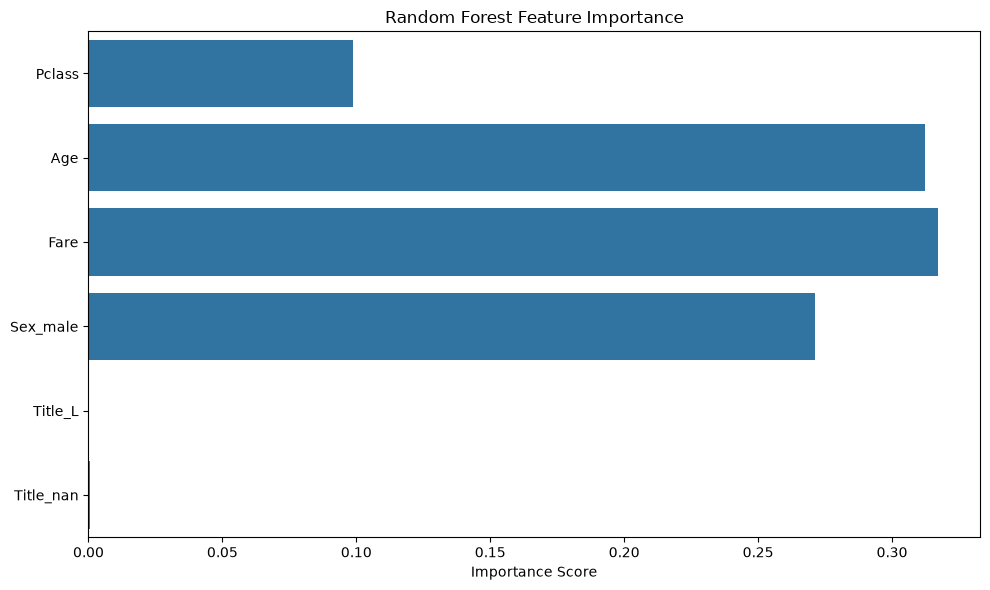

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- Classification Pipeline ---")
# Load dataset
df = pd.read_csv("titanic.csv")

# 1. Data Preprocessing & Feature Engineering
# Use direct assignment instead of inplace=True to comply with Pandas 2.0+
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Create new features only if the required base columns exist
if 'SibSp' in df.columns and 'Parch' in df.columns:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

if 'Name' in df.columns:
    # Use raw string (r'...') to fix SyntaxWarning
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 2. Dynamically Select Features
# List all features we WANT to use, then filter for what ACTUALLY exists in your CSV
desired_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
features = [col for col in desired_features if col in df.columns]

X = df[features]

if 'Survived' in df.columns:
    y = df['Survived']
else:
    raise KeyError("The target column 'Survived' was not found in the dataset.")

# Identify column types dynamically for the Pipeline
categorical_candidates = ['Sex', 'Embarked', 'Title']
numerical_candidates = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']

categorical_features = [col for col in categorical_candidates if col in X.columns]
numerical_features = [col for col in numerical_candidates if col in X.columns]

# 3. Create Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# 4. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Model Training & Evaluation
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': accuracy, 'F1-Score': f1}
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

# 6. Feature Importance Analysis (Random Forest)
rf_model = models['Random Forest']

# Extract feature names safely from the pipeline
cat_encoder = rf_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features)) if categorical_features else []
feature_names = numerical_features + cat_feature_names

importances = rf_model.named_steps['classifier'].feature_importances_

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()